# Training the sensing CNN on Gaussian-impulse data: initial vs. optimized design

This notebook actually **trains** a `TimeSeriesCNN` (from `neural_networks.py`)
for the initial and optimized 2-input-source design, on **one shared,
fixed train/test split**, and compares their test-loss history.

This is deliberately independent of the precomputed `nn_record` snapshots
in the original research pipeline. Those snapshots turned out to compare the
two designs against *different*, inconsistently-sampled held-out sets
(traced back to the original research notebook itself, which reports three
different numbers for the same initial-vs-optimized comparison depending on
which cell you read). Here, both designs are evaluated on exactly the same
held-out force samples, so the comparison is apples-to-apples.

`data/gaussian_impulse_nn_comparison.npz` pairs the initial design's
already-simulated response with the optimized design's response to the
*same* 300 force samples (the optimized-design response was computed with
the modular, already-validated `forward_simulation` package).

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax
import jax.numpy as jnp
import optax
from jaxopt import OptaxSolver
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

from neural_networks import TimeSeriesCNN, minmax_scaler

# Default setting
import matplotlib as mpl
import matplotlib
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]

## Load data and make one shared train/test split

The same `test_idx` is used to evaluate both the initial and the optimized
design, on the same force targets -- the only thing that differs between
the two runs below is which design's simulated sensor response is used as
the CNN's input.

In [2]:
data = np.load(DATA_DIR / "gaussian_impulse_nn_comparison.npz")
time = data["time"]
output_data = jnp.asarray(data["output_data"])                    # force targets, shared, (300, 200, 2)
input_data_initial = jnp.asarray(data["input_data_initial"])      # (300, 200, 3)
input_data_optimized = jnp.asarray(data["input_data_optimized"])  # (300, 200, 3)
print("output_data:", output_data.shape)
print("input_data_initial:", input_data_initial.shape)
print("input_data_optimized:", input_data_optimized.shape)

key = jax.random.PRNGKey(0)
n_samples = output_data.shape[0]
test_n = n_samples // 10
test_idx = jax.random.randint(key, shape=(test_n,), minval=0, maxval=n_samples)
train_mask = jnp.ones(n_samples, dtype=bool).at[test_idx].set(False)
print(f"train samples: {int(train_mask.sum())}, test samples: {test_n}")

output_data: (300, 200, 2)
input_data_initial: (300, 200, 3)
input_data_optimized: (300, 200, 3)


train samples: 271, test samples: 30


## Train one CNN and track test loss history

In [3]:
def train_and_track(input_data, output_data, train_mask, test_idx, scaler, iters=1000, lr=1e-2, eval_every=5, seed=0):
    train_x, train_y = input_data[train_mask], output_data[train_mask]
    test_x, test_y = input_data[test_idx], output_data[test_idx]

    train_xn, train_yn = scaler.transform(train_x, train_y)
    test_xn, test_yn = scaler.transform(test_x, test_y)

    model = TimeSeriesCNN(output_features=output_data.shape[-1])
    params = model.init(jax.random.PRNGKey(seed), train_xn)

    def loss_fn(params, data):
        x, y = data
        pred = model.apply(params, x)
        return jnp.mean((pred - y) ** 2)

    solver = OptaxSolver(opt=optax.adam(lr), fun=loss_fn, maxiter=iters)
    state = solver.init_state(params, (train_xn, train_yn))

    history = []
    for i in range(iters):
        params, state = solver.update(params, state, (train_xn, train_yn))
        if i % eval_every == 0 or i == iters - 1:
            test_loss = float(loss_fn(params, (test_xn, test_yn)))
            history.append((i, test_loss))

    return params, history

In [4]:
# Fit one scaler from the initial design's training data and reuse it for
# both conditions -- matching the original research notebook's convention
# (a single scaler computed once, reused for the optimized design too),
# rather than letting each design normalize on its own scale.
scaler = minmax_scaler(input_data_initial[train_mask], output_data[train_mask])

params_initial, history_initial = train_and_track(input_data_initial, output_data, train_mask, test_idx, scaler)
params_optimized, history_optimized = train_and_track(input_data_optimized, output_data, train_mask, test_idx, scaler)

print(f"final test loss, initial design:   {history_initial[-1][1]:.4e}")
print(f"final test loss, optimized design: {history_optimized[-1][1]:.4e}")

(1, 1, 3) (1, 1, 3)


(1, 1, 2) (1, 1, 2)


final test loss, initial design:   1.0928e-03
final test loss, optimized design: 4.3984e-04


## Test loss history: initial vs. optimized design

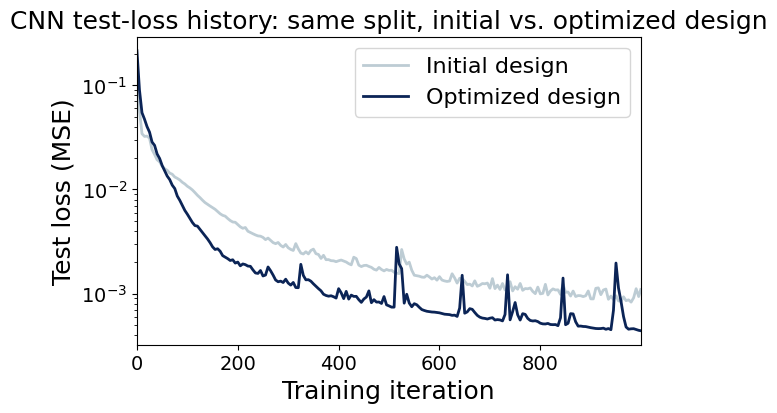

In [5]:
iters_i, loss_i = zip(*history_initial)
iters_o, loss_o = zip(*history_optimized)

plt.figure(figsize=(6.5, 4))
plt.semilogy(iters_i, loss_i, color=COLORS[1], label="Initial design")
plt.semilogy(iters_o, loss_o, color=COLORS[2], label="Optimized design")
plt.xlabel("Training iteration")
plt.ylabel("Test loss (MSE)")
plt.title("CNN test-loss history: same split, initial vs. optimized design")
plt.legend()
plt.show()